In [2]:
!pip install ultralytics -q
from ultralytics import YOLO
import os

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 472.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 8.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [3]:
!kaggle datasets download -d pkdarabi/bone-fracture-detection-computer-vision-project -p /content/raw_data
!unzip -q /content/raw_data/*.zip -d /content/raw_data
!rm /content/raw_data/*.zip

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/bone-fracture-detection-computer-vision-project
License(s): Attribution 4.0 International (CC BY 4.0)
100% 84.1M/84.1M [00:06<00:00, 13.2MB/s]



In [4]:
import os
for root, dirs, files_ in os.walk('/content/raw_data'):
    level = root.replace('/content/raw_data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files_[:3]:
            print(f'{indent}  {f}')

raw_data/
  BoneFractureYolo8/
    data.yaml
    README.dataset.txt
    valid/
      labels/
      images/
    test/
      labels/
      images/
    train/
      labels/
      images/
  bone fracture detection.v4-v4.yolov8/
    data.yaml
    README.dataset.txt
    valid/
      labels/
      images/
    test/
      labels/
      images/
    train/
      labels/
      images/


In [5]:
!find /content/raw_data -name "*.yaml"

/content/raw_data/BoneFractureYolo8/data.yaml
/content/raw_data/bone fracture detection.v4-v4.yolov8/data.yaml


In [6]:
import yaml
yaml_path = !find /content/raw_data -name "*.yaml"
yaml_path = yaml_path[0]
with open(yaml_path) as f:
    config = yaml.safe_load(f)
print(config)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 7, 'names': ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive'], 'roboflow': {'workspace': 'veda', 'project': 'bone-fracture-detection-daoon', 'version': 4, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/veda/bone-fracture-detection-daoon/dataset/4'}}


In [7]:
import subprocess
yaml_path = subprocess.getoutput('find /content/raw_data -name "*.yaml"').split('\n')[0]
print("Using yaml:", yaml_path)

import yaml
with open(yaml_path) as f:
    config = yaml.safe_load(f)
print(config)

Using yaml: /content/raw_data/BoneFractureYolo8/data.yaml
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 7, 'names': ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive'], 'roboflow': {'workspace': 'veda', 'project': 'bone-fracture-detection-daoon', 'version': 4, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/veda/bone-fracture-detection-daoon/dataset/4'}}


In [8]:
base_dir = os.path.dirname(yaml_path)
config['train'] = os.path.join(base_dir, 'train', 'images')
config['val'] = os.path.join(base_dir, 'valid', 'images')
if 'test' in config:
    config['test'] = os.path.join(base_dir, 'test', 'images')

with open(yaml_path, 'w') as f:
    yaml.dump(config, f)

print("Updated config:", config)

Updated config: {'train': '/content/raw_data/BoneFractureYolo8/train/images', 'val': '/content/raw_data/BoneFractureYolo8/valid/images', 'test': '/content/raw_data/BoneFractureYolo8/test/images', 'nc': 7, 'names': ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive'], 'roboflow': {'workspace': 'veda', 'project': 'bone-fracture-detection-daoon', 'version': 4, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/veda/bone-fracture-detection-daoon/dataset/4'}}


In [9]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # nano version — fastest, good for a same-day project

results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    name='fracture_detection'
)

Ultralytics 8.4.145 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/raw_data/BoneFractureYolo8/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fracture_detection, nbs=64, nms

In [10]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.145 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 532.3±253.6 MB/s, size: 8.9 KB)
val: Scanning /content/raw_data/BoneFractureYolo8/valid/labels.cache... 348 images, 175 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 348/348 104.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 6.0it/s 3.7s
                   all        348        204      0.468      0.292      0.297      0.106
        elbow positive         28         29      0.199      0.138     0.0801      0.021
      fingers positive         41         48       0.39      0.292      0.173     0.0547
      forearm fracture         37         43      0.719      0.512      0.585      0.217
               humerus         31         36      0.883      0.528       0.62      0.219
     shoulder fracture      


0: 640x640 (no detections), 3.6ms
1: 640x640 (no detections), 3.6ms
2: 640x640 1 shoulder fracture, 3.6ms
3: 640x640 (no detections), 3.6ms
4: 640x640 (no detections), 3.6ms
5: 640x640 1 fingers positive, 3.6ms
6: 640x640 (no detections), 3.6ms
7: 640x640 1 forearm fracture, 3.6ms
8: 640x640 (no detections), 3.6ms
9: 640x640 1 elbow positive, 3.6ms
10: 640x640 (no detections), 3.6ms
11: 640x640 (no detections), 3.6ms
12: 640x640 (no detections), 3.6ms
13: 640x640 (no detections), 3.6ms
14: 640x640 (no detections), 3.6ms
15: 640x640 (no detections), 3.6ms
16: 640x640 1 shoulder fracture, 3.6ms
17: 640x640 (no detections), 3.6ms
18: 640x640 (no detections), 3.6ms
19: 640x640 (no detections), 3.6ms
20: 640x640 1 fingers positive, 1 wrist positive, 3.6ms
21: 640x640 1 shoulder fracture, 3.6ms
22: 640x640 1 fingers positive, 3.6ms
23: 640x640 (no detections), 3.6ms
24: 640x640 1 shoulder fracture, 3.6ms
25: 640x640 (no detections), 3.6ms
26: 640x640 (no detections), 3.6ms
27: 640x640 (no d

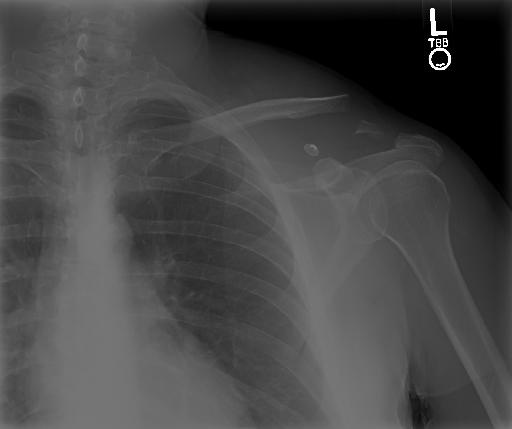

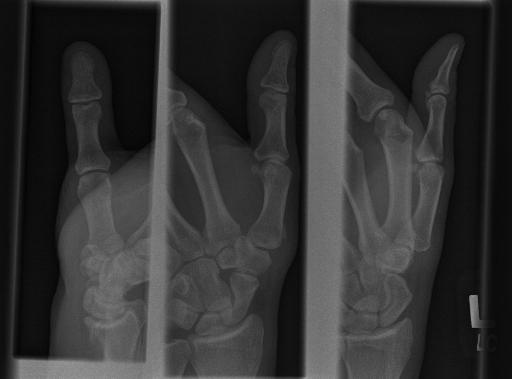

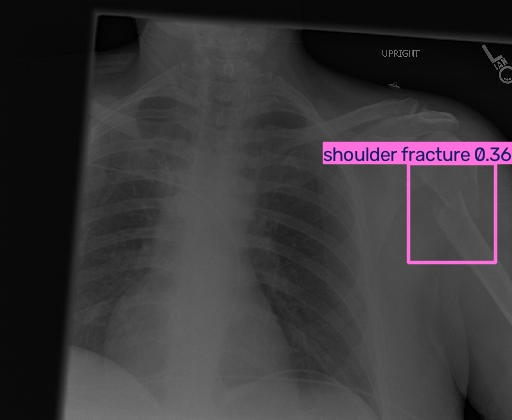

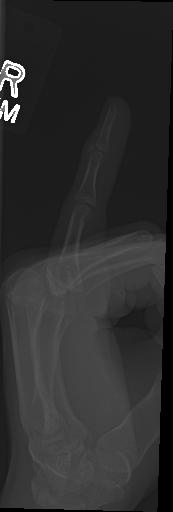

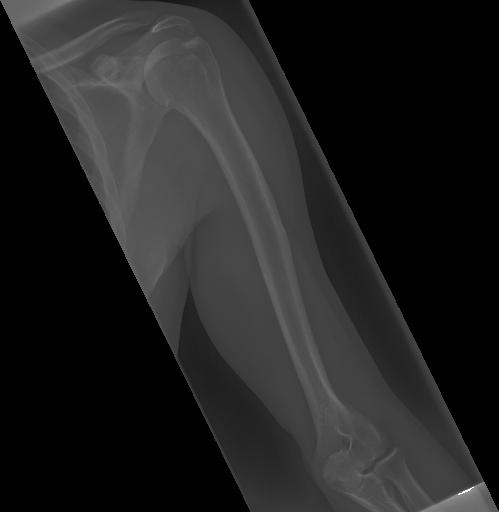

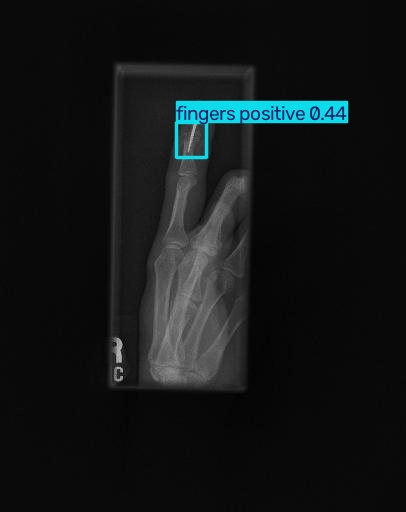

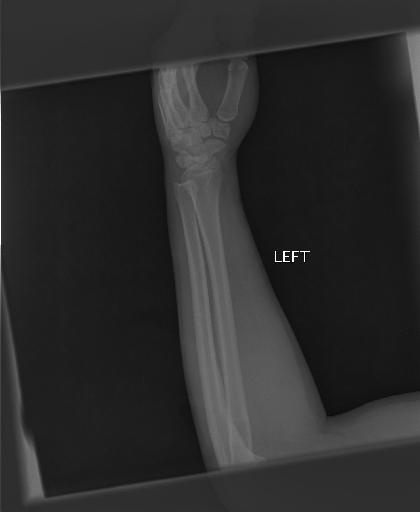

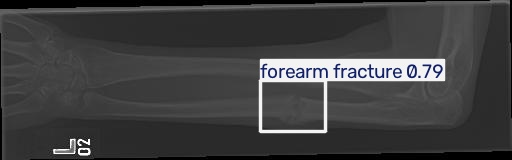

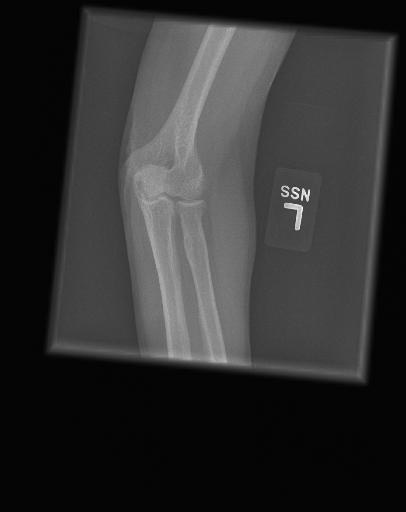

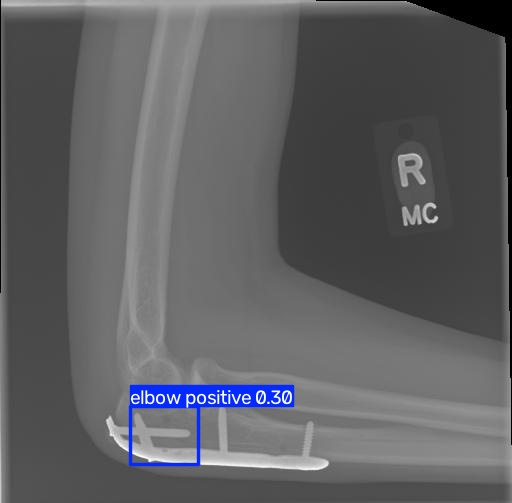

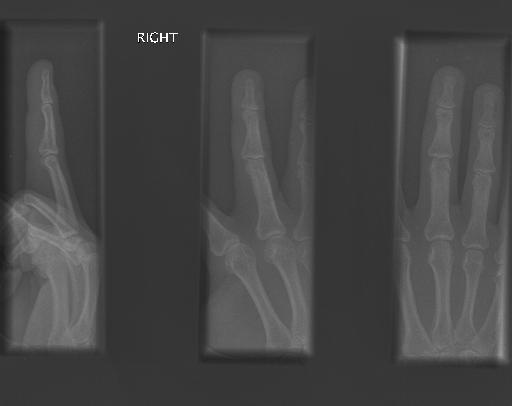

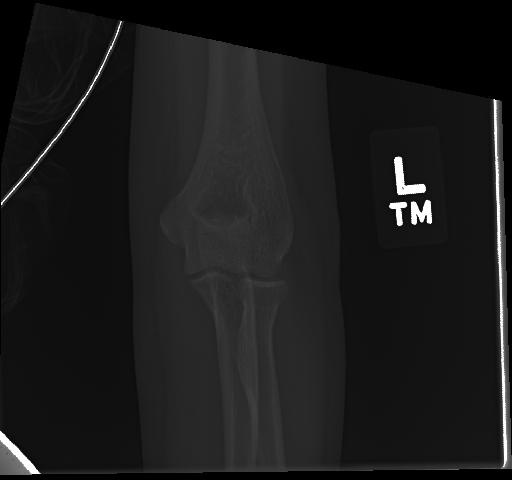

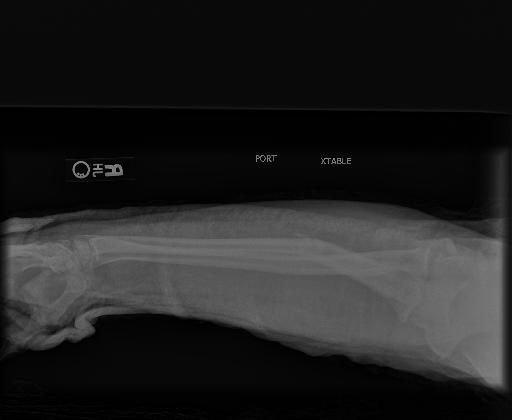

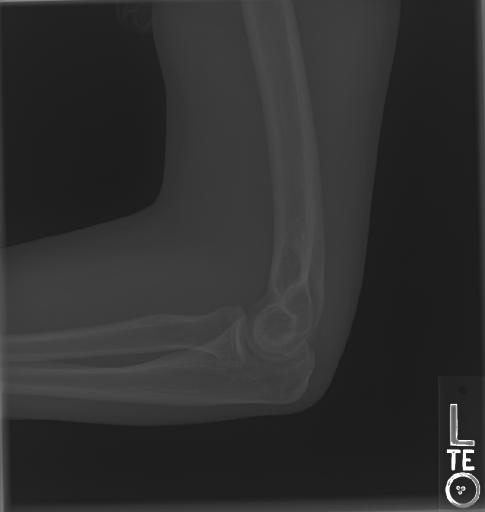

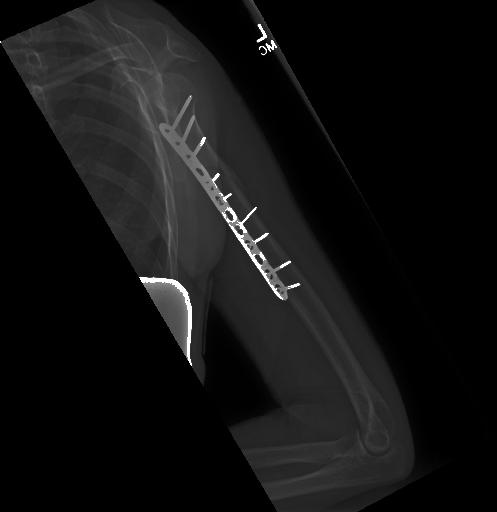

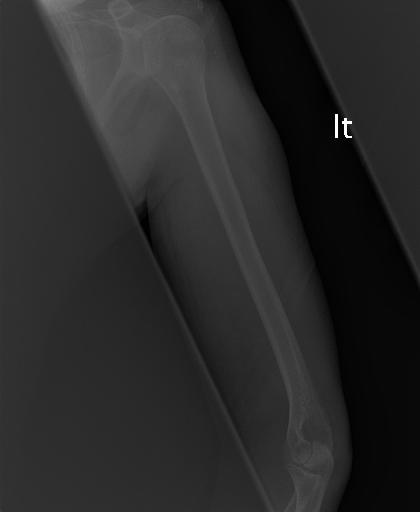

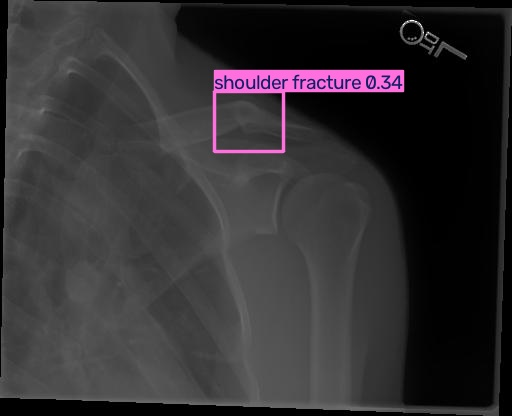

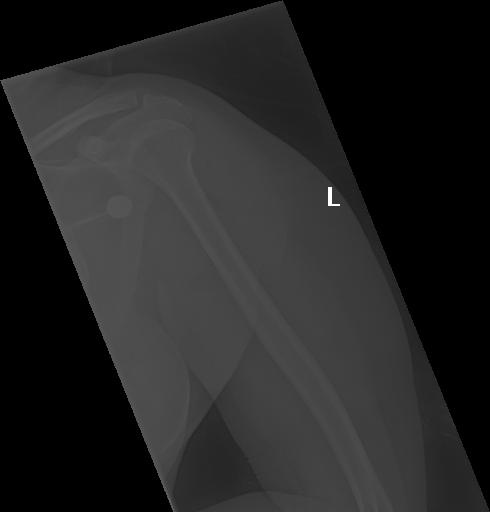

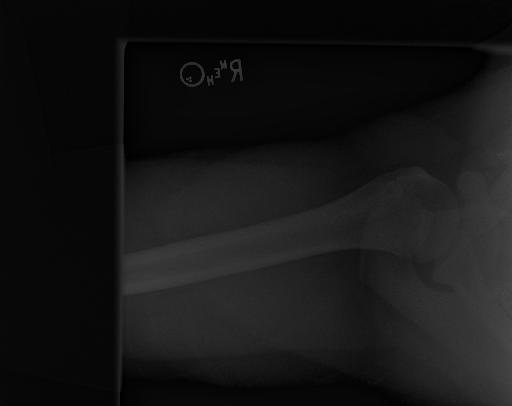

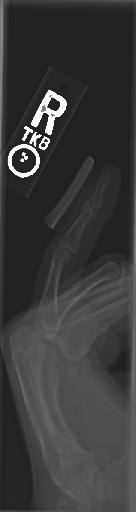

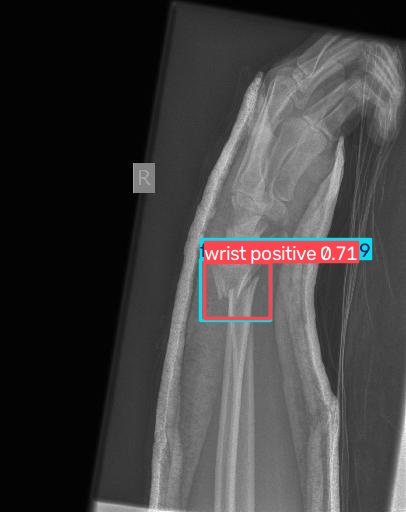

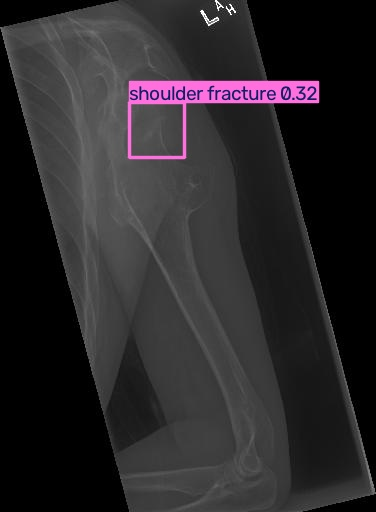

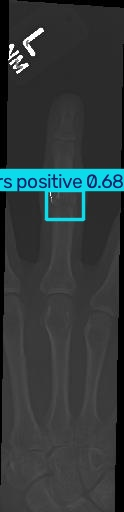

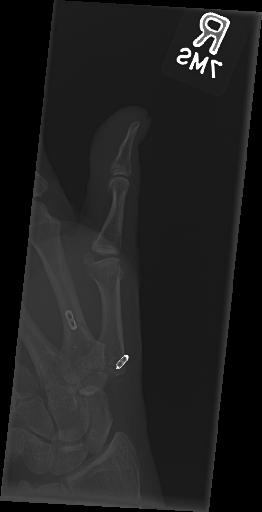

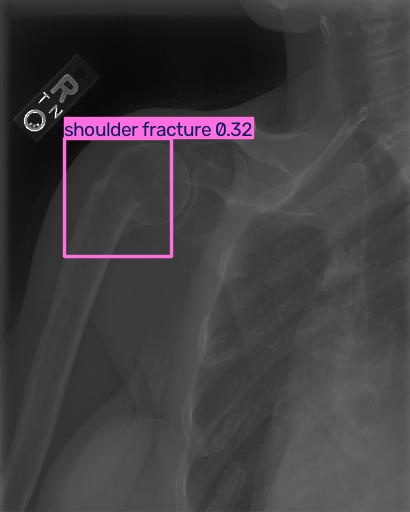

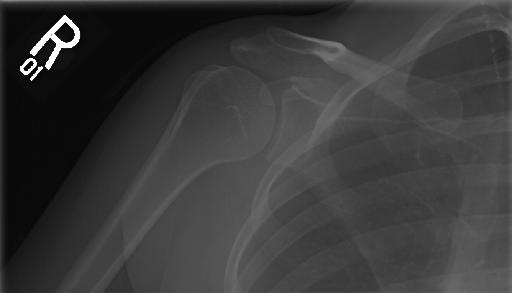

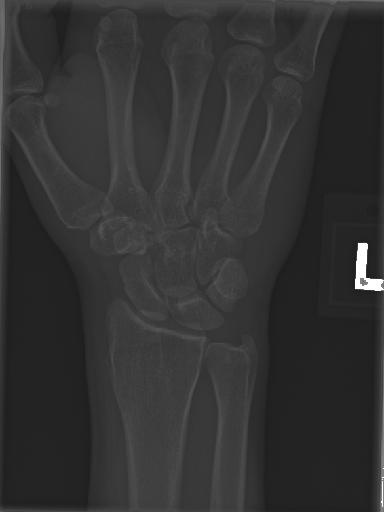

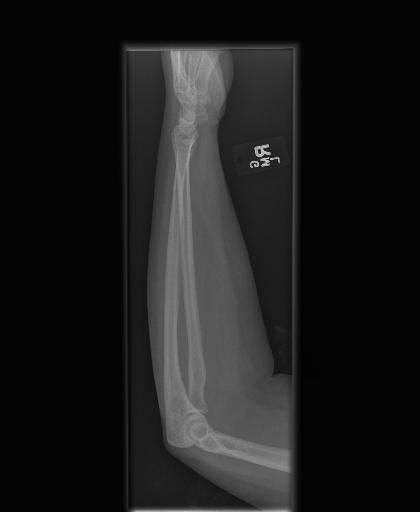

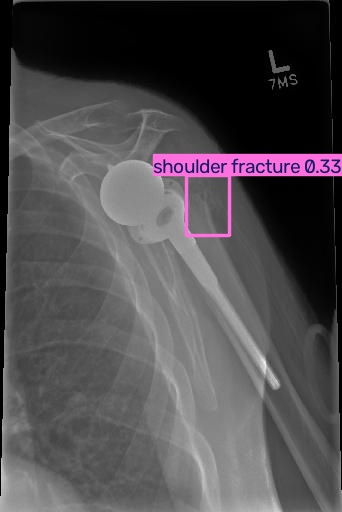

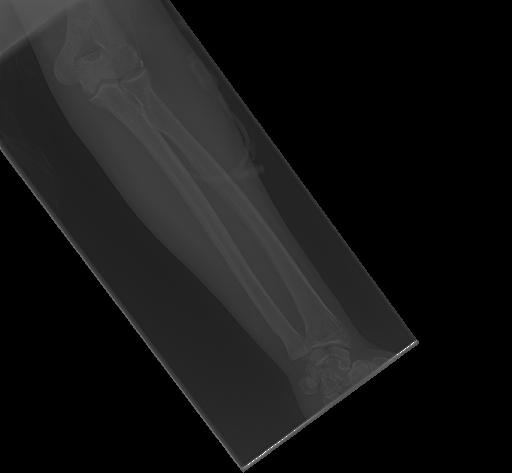

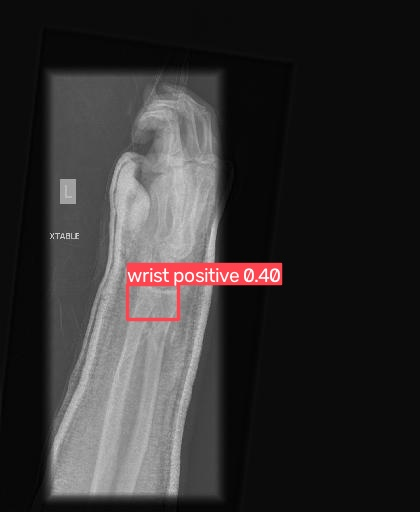

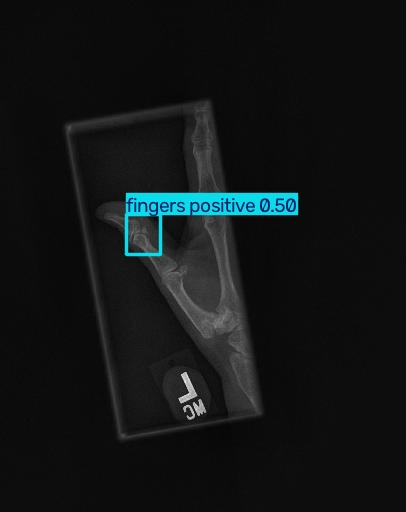

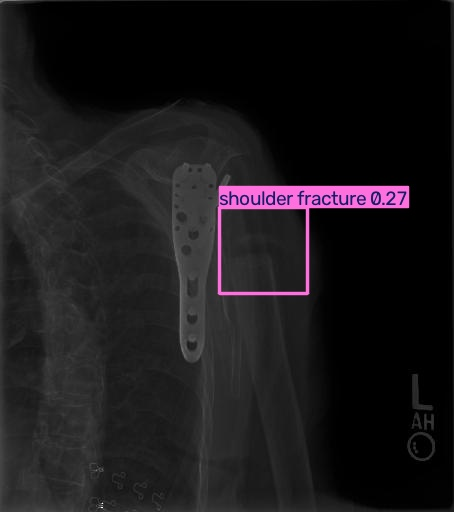

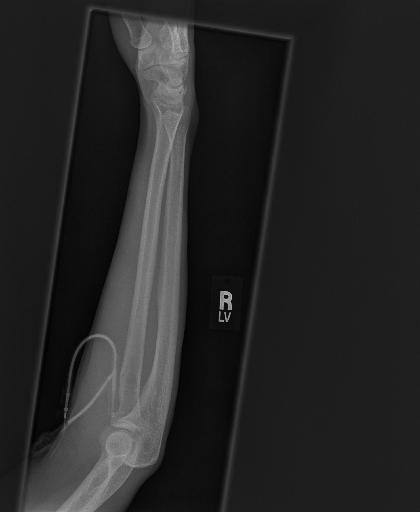

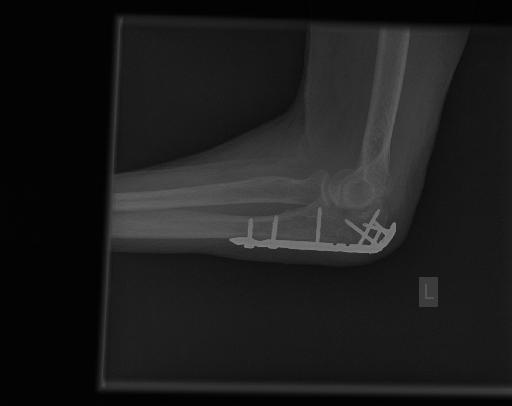

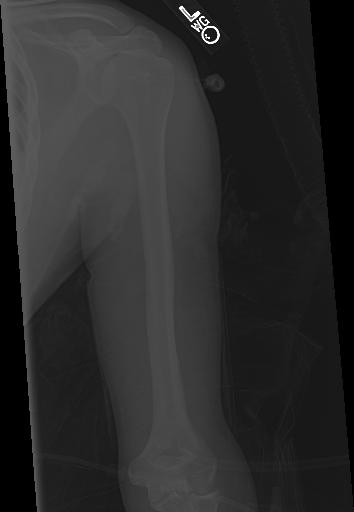

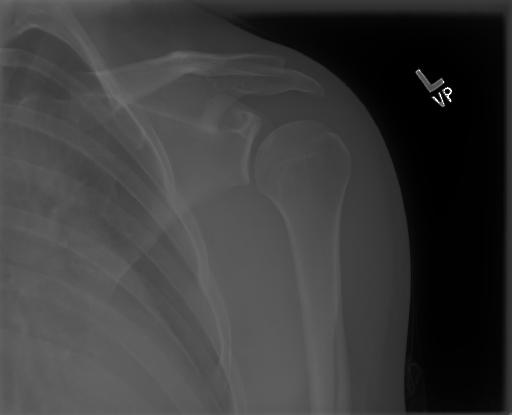

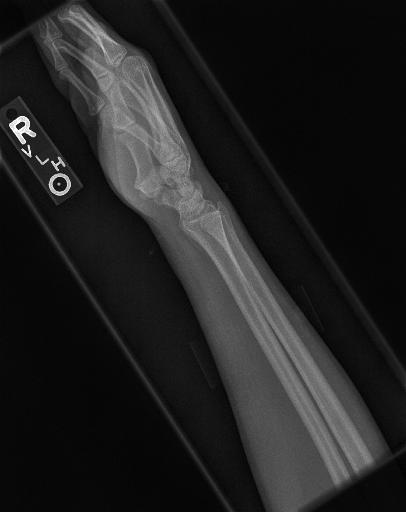

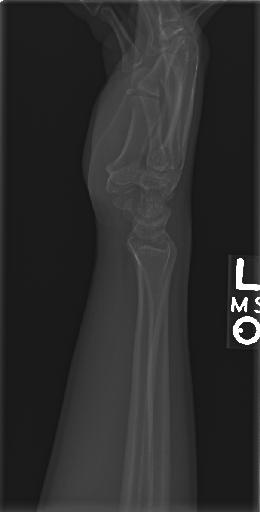

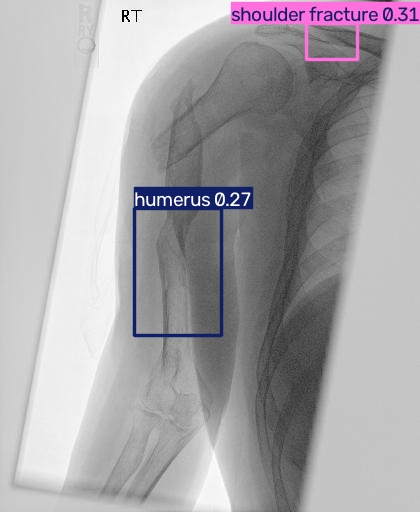

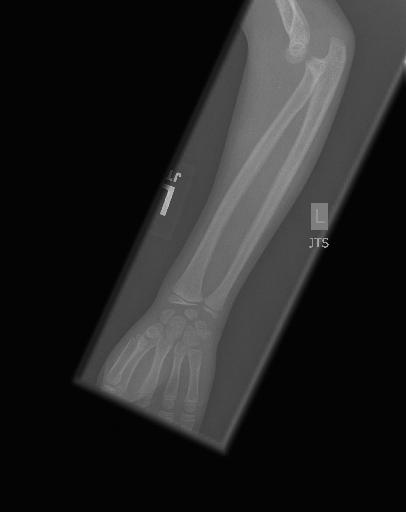

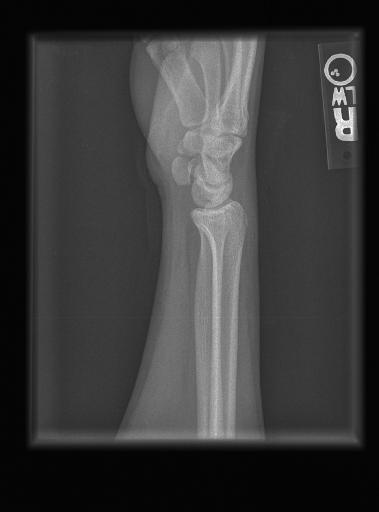

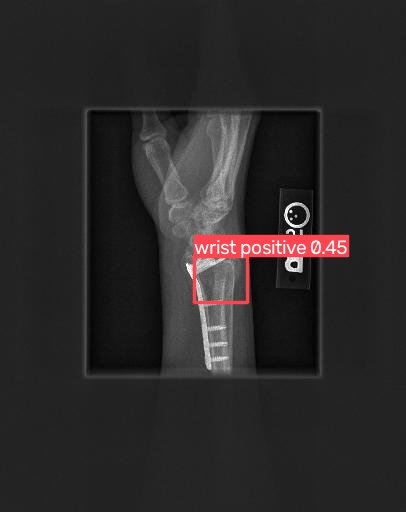

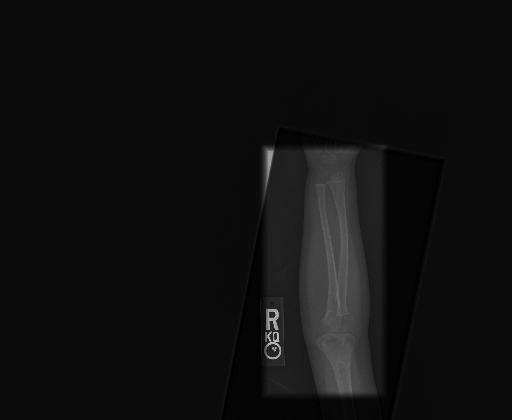

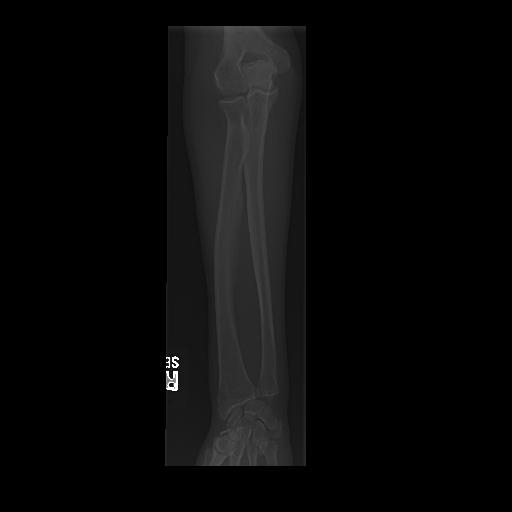

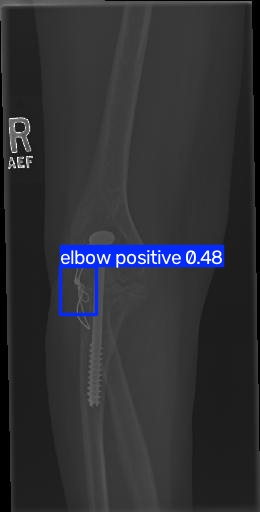

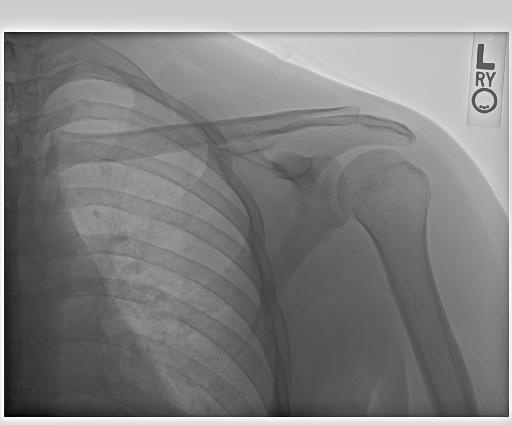

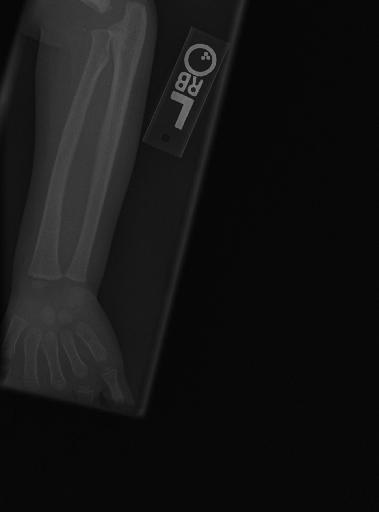

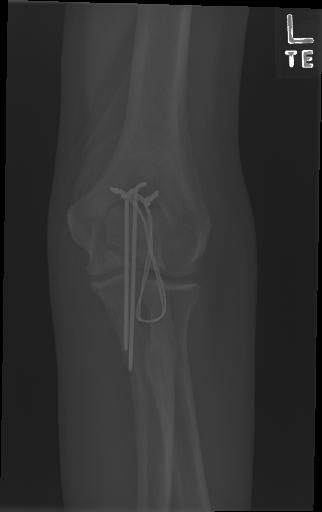

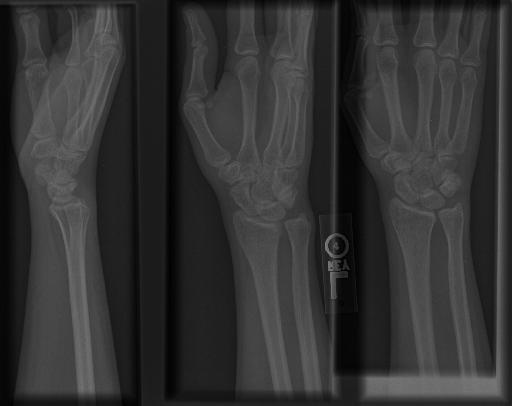

In [11]:
import glob
test_images = glob.glob(f'{base_dir}/test/images/*.jpg')[:50]
results = model.predict(test_images, save=True, conf=0.25)

# display results
from IPython.display import Image as IPImage, display
for r in results[:50]:
    display(IPImage(filename=r.save_dir + '/' + os.path.basename(r.path)))

In [14]:
from google.colab import files

files.download('/content/runs/detect/fracture_detection/weights/best.pt')
files.download('/content/runs/detect/fracture_detection/results.png')
files.download('/content/runs/detect/fracture_detection/confusion_matrix.png')
files.download('/content/runs/detect/fracture_detection/BoxPR_curve.png')

# bonus: ready-made prediction visualizations, no extra code needed
files.download('/content/runs/detect/fracture_detection/val_batch0_pred.jpg')
files.download('/content/runs/detect/fracture_detection/val_batch1_pred.jpg')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import os
for f in os.listdir('/content/runs/detect/fracture_detection'):
    print(f)

train_batch1.jpg
val_batch0_labels.jpg
val_batch1_pred.jpg
BoxP_curve.png
weights
BoxF1_curve.png
train_batch0.jpg
BoxPR_curve.png
train_batch2.jpg
args.yaml
results.csv
train_batch4541.jpg
confusion_matrix_normalized.png
val_batch2_pred.jpg
train_batch4542.jpg
val_batch1_labels.jpg
BoxR_curve.png
val_batch2_labels.jpg
confusion_matrix.png
results.png
labels.jpg
train_batch4540.jpg
val_batch0_pred.jpg
